In [5]:
import time
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from skimage import measure

import sys, os
sys.path.append(os.path.abspath("../src"))

from core.cell import CellConfig
from core.perception import PerceptionConfig
from core.update import UpdateConfig
from core.grid import Grid3D, GridConfig

In [6]:
def make_sphere_target(grid_size, radius, device='cpu'):
    D, H, W = grid_size
    cz, cy, cx = D / 2.0, H / 2.0, W / 2.0
    zz = torch.arange(0, D, device=device).view(D, 1, 1).expand(D, H, W).float()
    yy = torch.arange(0, H, device=device).view(1, H, 1).expand(D, H, W).float()
    xx = torch.arange(0, W, device=device).view(1, 1, W).expand(D, H, W).float()
    dist = torch.sqrt((zz - cz) ** 2 + (yy - cy) ** 2 + (xx - cx) ** 2)
    occ = (dist <= radius).float()
    return occ.unsqueeze(0).unsqueeze(0)

In [7]:
def train_multi_step(model: Grid3D, cell_cfg: CellConfig, grid_cfg: GridConfig,
                     device='cpu', iters=2000, n_steps=8, log_interval=200):
    model.to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

    target = make_sphere_target(grid_cfg.size, radius=min(grid_cfg.size)/4.0, device=device)

    losses = []
    for it in range(1, iters+1):
        state = model.seed_center(batch_size=1, device=device)
        state += 0.02 * torch.randn_like(state)

        optim.zero_grad()
        loss = 0.0
        for step in range(n_steps):
            state = model(state, steps=1)
            alpha = state[:, -1:, ...]
            loss += F.mse_loss(alpha, target)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()

        losses.append(loss.item())

        if it % log_interval == 0 or it==1:
            print(f"iter {it:05d} loss={loss.item():.6f} mean_alpha={alpha.mean().item():.4f}")
            show_idx = alpha.shape[2]//2
            plt.figure(figsize=(8,4))
            plt.subplot(1,2,1)
            plt.imshow(target[0,0,show_idx].cpu(), vmin=0, vmax=1)
            plt.title('target center slice')
            plt.axis('off')
            plt.subplot(1,2,2)
            plt.imshow(alpha[0,0,show_idx].detach().cpu(), vmin=0, vmax=1)
            plt.title(f'output center slice (iter {it})')
            plt.axis('off')
            plt.show()

    return losses


device -> cuda
stability run:
step 00 mean=+0.000003 std=0.001842
step 01 mean=+0.000003 std=0.001845
step 02 mean=+0.000003 std=0.001856
step 03 mean=+0.000003 std=0.001898
step 04 mean=+0.000002 std=0.002058
step 05 mean=+0.000001 std=0.002603
step 06 mean=-0.000001 std=0.004114
step 07 mean=-0.000006 std=0.007585

starting single-step supervised training (tiny)
iter 00001 loss=0.953562 mean_alpha=0.0073


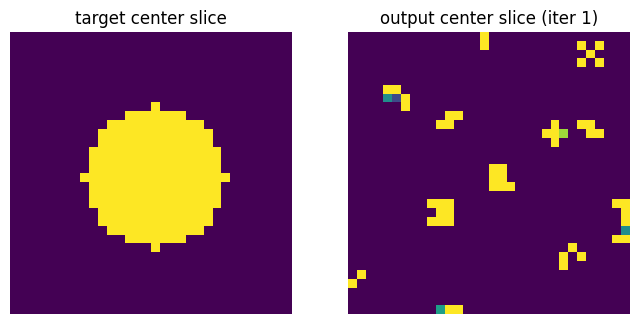

iter 00200 loss=0.482949 mean_alpha=0.0252


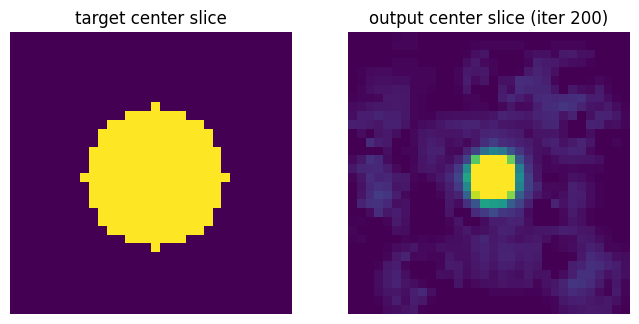

iter 00400 loss=0.398205 mean_alpha=0.0414


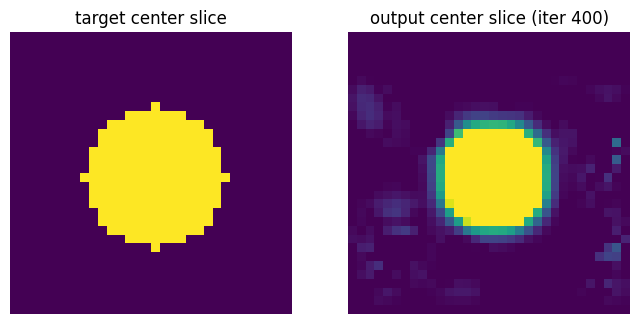

iter 00600 loss=0.389358 mean_alpha=0.0737


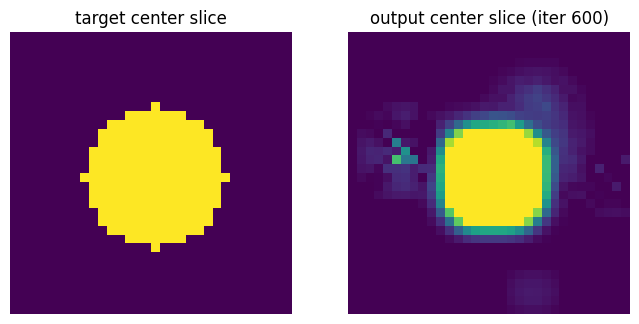

iter 00800 loss=0.371345 mean_alpha=0.0529


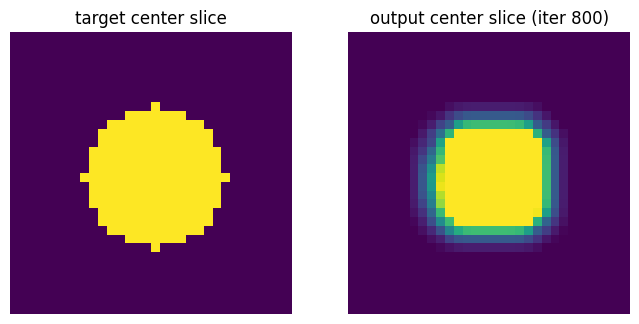

iter 01000 loss=0.367753 mean_alpha=0.0619


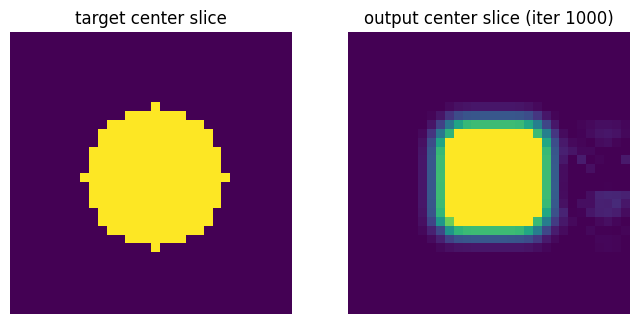

iter 01200 loss=0.521650 mean_alpha=0.2035


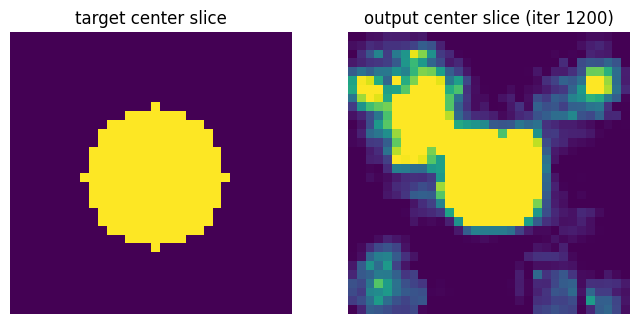

iter 01400 loss=0.371815 mean_alpha=0.0955


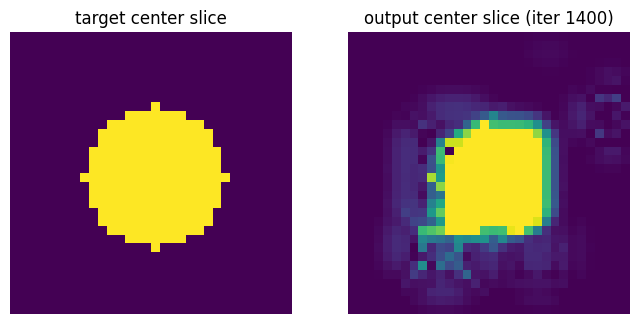

iter 01600 loss=0.367975 mean_alpha=0.0645


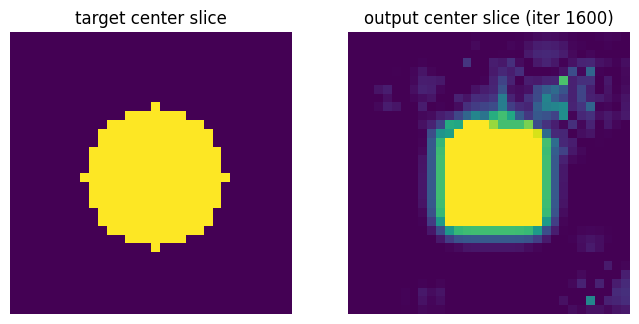

iter 01800 loss=0.360706 mean_alpha=0.0620


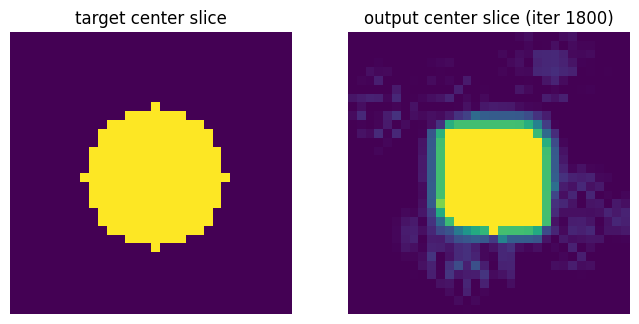

iter 02000 loss=0.352480 mean_alpha=0.0617


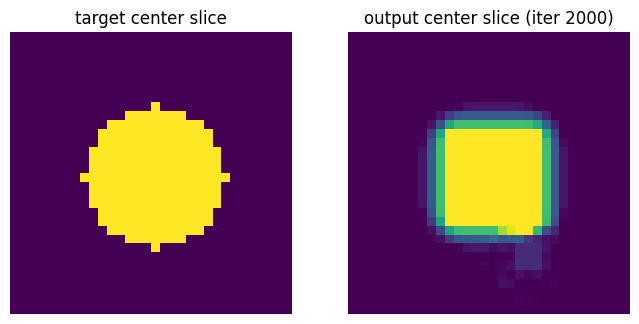

training took 93.35875463485718 s
final alive voxels: 2713


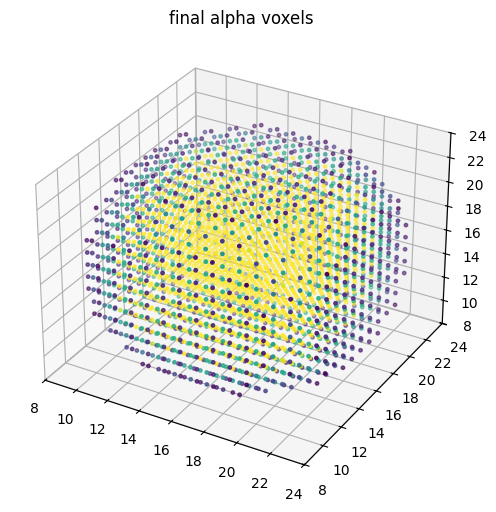

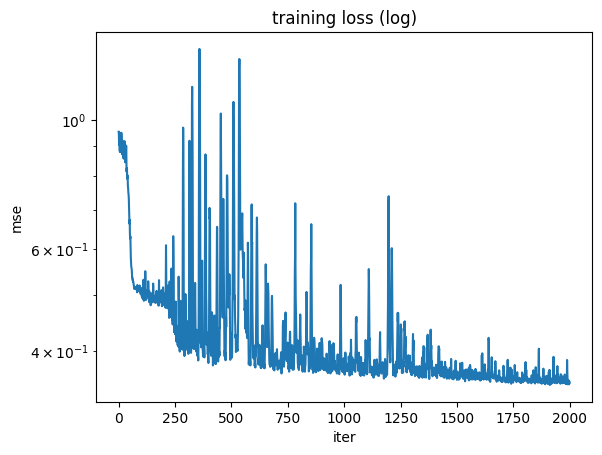

In [8]:
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("device ->", device)

    cell_cfg = CellConfig(hidden_channels=8, visible_channels=1, alive_threshold=0.05)
    perc_cfg = PerceptionConfig(kernel_radius=1, channel_groups=3)
    upd_cfg = UpdateConfig(hidden_dim=64, stochastic_update=False, fire_rate=0.5)
    grid_cfg = GridConfig(size=(32, 32, 32))

    model = Grid3D(cell_cfg, perc_cfg, upd_cfg, grid_cfg).to(device)

    print("stability run:")
    state = model.seed_center(batch_size=1, device=device)
    state += 1e-3 * torch.randn_like(state)
    with torch.no_grad():
        for i in range(8):
            state = model(state, steps=1)
            print(f"step {i:02d} mean={state.mean().item():+.6f} std={state.std().item():.6f}")

    print("\nstarting single-step supervised training (tiny)")
    start = time.time()
    losses = train_multi_step(model, cell_cfg, grid_cfg, device=device)
    print("training took", time.time() - start, "s")

    with torch.no_grad():
        state = model.seed_center(batch_size=1, device=device)
        state += 1e-3 * torch.randn_like(state)
        state = model(state, steps=8)
        alpha = state[:, -1:, ...].cpu().numpy().squeeze()

    thresh = 0.2
    xs, ys, zs = np.nonzero(alpha > thresh)
    print("final alive voxels:", len(xs))

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(xs, ys, zs, s=6, c=alpha[alpha > thresh])
    ax.set_title("final alpha voxels")
    plt.show()

    plt.figure()
    plt.plot(losses)
    plt.yscale("log")
    plt.title("training loss (log)")
    plt.xlabel("iter")
    plt.ylabel("mse")
    plt.show()